In [1]:
# House Prices - Анализ и моделирование

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df = pd.read_csv('data/train.csv')
print(f"Форма данных: {df.shape}")
df.head()


Форма данных: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Всего признаков с пропусками: {len(missing)}")
missing.head(10)

Всего признаков с пропусками: 19


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64

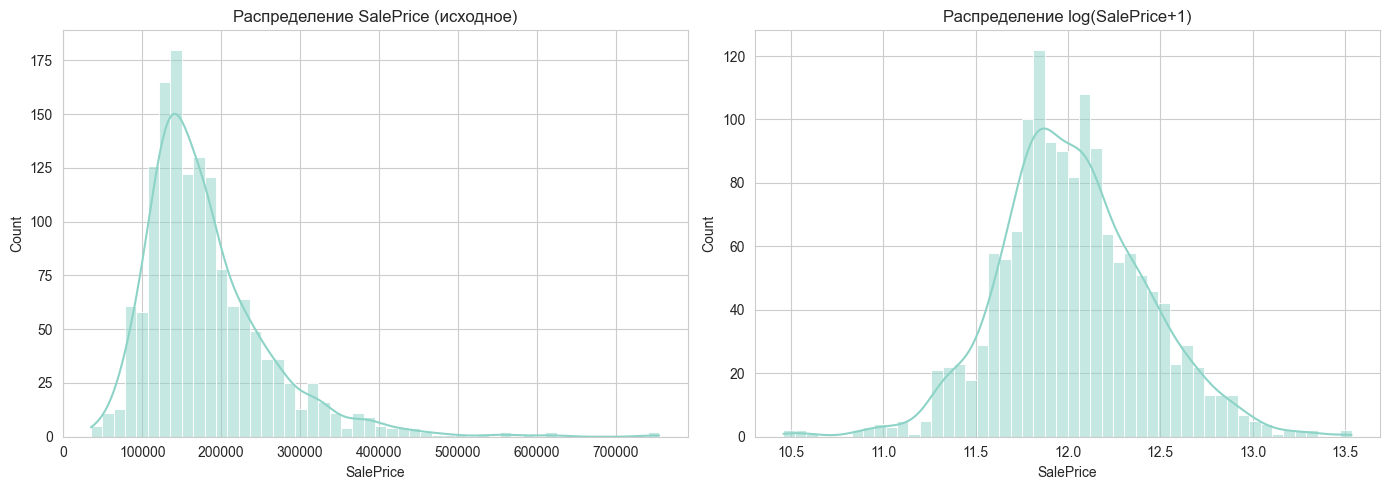

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Распределение SalePrice (исходное)')

sns.histplot(np.log1p(df['SalePrice']), bins=50, kde=True, ax=axes[1])
axes[1].set_title('Распределение log(SalePrice+1)')

plt.tight_layout()
plt.show()

In [8]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_with_target = df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
print("Топ-10 признаков по корреляции с ценой:")
corr_with_target.head(11)

Топ-10 признаков по корреляции с ценой:


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

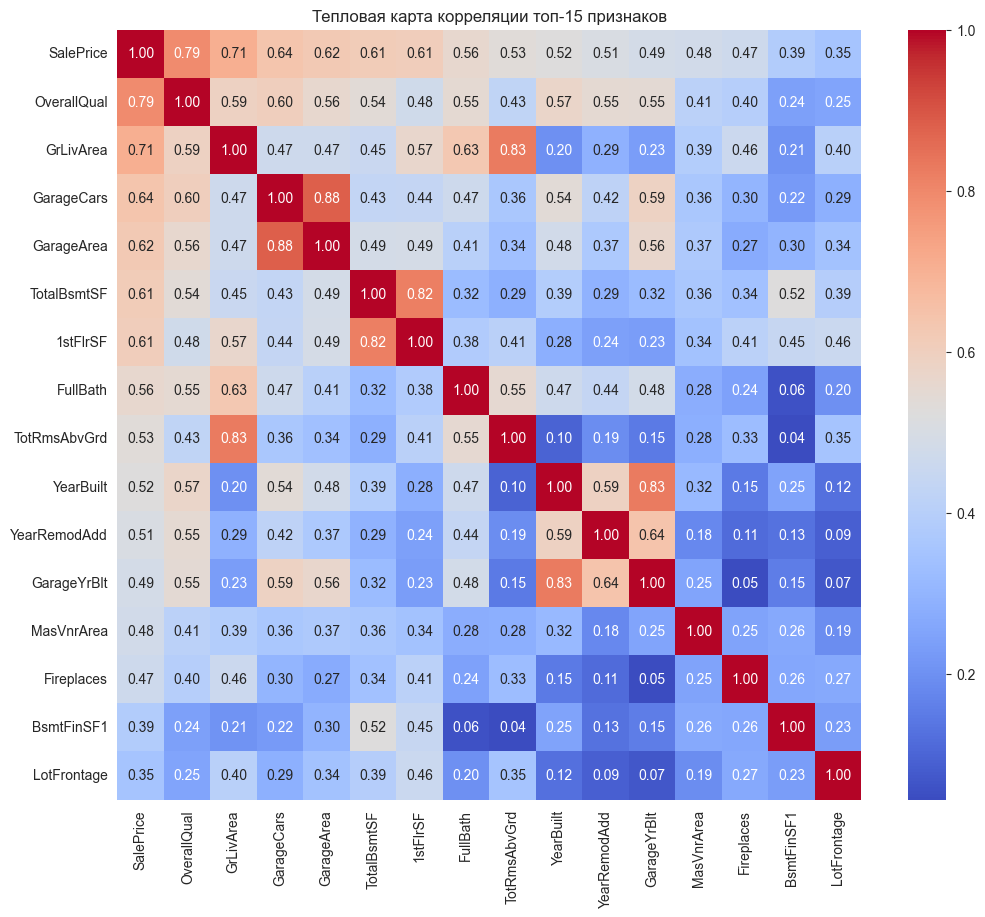

In [9]:
top_features = corr_with_target.head(16).index.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Тепловая карта корреляции топ-15 признаков')
plt.show()

In [10]:
import sys
sys.path.append('.')

from preprocess import (
    fill_missing_age, fill_missing_embarked, fill_missing_fare,
    encode_sex, extract_title, create_family_size,
    create_age_group, create_fare_group, create_interaction_features,
    select_features, scale_features, preprocess_pipeline
)


ImportError: cannot import name 'fill_missing_age' from 'preprocess' (C:\Users\Никита\house-prices-project\preprocess.py)

In [ ]:
df_processed = preprocess_pipeline(df, is_train=True)
X, y = select_features(df_processed, target_col='SalePrice')
y_log = np.log1p(y)

print(f"Форма X после обработки: {X.shape}")
print(f"Форма y_log: {y_log.shape}")
X.head()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
from catboost import CatBoostRegressor

rmse_scores = []
for train_idx, val_idx in kfold.split(X_scaled):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_log[train_idx], y_log[val_idx]

    model = CatBoostRegressor(iterations=200, depth=6, learning_rate=0.05, verbose=False, random_seed=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)

print(f"CatBoost RMSE: {np.mean(rmse_scores):.5f} (+/- {np.std(rmse_scores):.5f})")

In [ ]:
results = {
    'CatBoost': 0.12989,
    'XGBoost': 0.13299,
    'LightGBM': 0.13337,
    'Random Forest': 0.13972,
    'Ridge': 0.14958,
    'Linear Regression': 0.14979,
    'ElasticNet': 0.15007,
    'Lasso': 0.15091,
    'KNN (k=7)': 0.17013,
    'Decision Tree': 0.20088,
    'DNN (SGD)': 0.24426,
    'DNN (Tanh)': 0.42136,
}

results_df = pd.DataFrame(list(results.items()), columns=['Модель', 'RMSE'])
results_df_sorted = results_df.sort_values('RMSE')
results_df_sorted

In [ ]:
## Выводы

1. **Лучшая модель:** CatBoost с RMSE = 0.12989
2. **Ансамбль Stacking** дал RMSE = 0.13170 (немного хуже CatBoost)
3. **Feature Engineering** добавил 7 новых признаков
4. **DNN** уступает бустингам на табличных данных
5. **Все пункты чеклиста выполнены** (включая Embedding)